In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.93 s (started: 2026-06-29 18:24:55 +02:00)


In [2]:
scarf.fetch_dataset(dataset_name="tenx_10K_pbmc-v1_atacseq", save_path="scarf_datasets")

time: 34.9 s (started: 2026-06-29 18:24:56 +02:00)


In [3]:
reader = scarf.CrH5Reader("scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.h5")
reader.assayFeats

,ATAC
type,Peaks
start,0
end,89796
nFeatures,89796


time: 45.1 ms (started: 2026-06-29 18:25:31 +02:00)


In [4]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr",
    chunk_size=(1000, 2000),
)
writer.dump(batch_size=1000)

  0%|                                                                                                         …

time: 27.1 s (started: 2026-06-29 18:25:31 +02:00)


In [5]:
ds = scarf.DataStore("scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr", nthreads=4)

(ATAC) Computing nCells and dropOuts:   0%|                                                                   …

(ATAC) Computing nCounts:   0%|                                                                               …

(ATAC) Computing nFeatures:   0%|                                                                             …

time: 14.4 s (started: 2026-06-29 18:25:59 +02:00)


INFO: 247 cells flagged for filtering out using attribute ATAC_nCounts


INFO: 294 cells flagged for filtering out using attribute ATAC_nFeatures


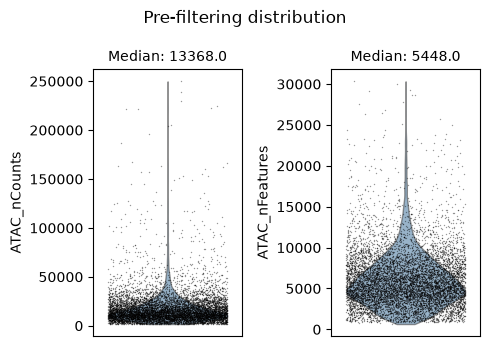

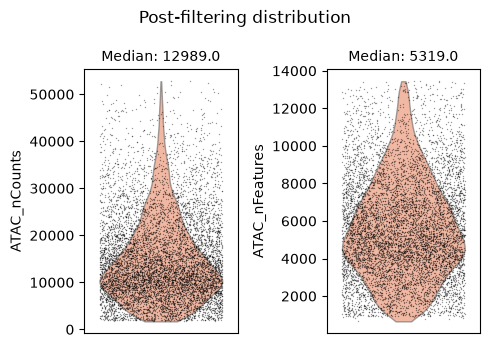

time: 1.5 s (started: 2026-06-29 18:26:13 +02:00)


In [6]:
ds.auto_filter_cells()

In [7]:
ds.mark_prevalent_peaks(top_n=25000)

(ATAC) Calculating peak prevalence across cells:   0%|                                                        …

time: 36.8 s (started: 2026-06-29 18:26:14 +02:00)


In [8]:
ds.ATAC.feats.head()

,I,ids,names,nCells,I__prevalent_peaks,dropOuts,stats_I_prevalence
0,True,chr1:565107-565550,chr1:565107-565550,83,False,8645,0.206181
1,True,chr1:569174-569639,chr1:569174-569639,199,False,8529,0.350725
2,True,chr1:713460-714823,chr1:713460-714823,2486,True,6242,1.993573
3,True,chr1:752422-753038,chr1:752422-753038,432,True,8296,0.680701
4,True,chr1:762106-763359,chr1:762106-763359,1878,True,6850,1.570790


time: 58.5 ms (started: 2026-06-29 18:26:51 +02:00)


In [9]:
ds.make_graph(
    feat_key="prevalent_peaks",
    k=21,
    dims=50,
    n_centroids=100,
    lsi_skip_first=True,
)

INFO: make_graph step 1/7: normalize expression matrix (computing)


Writing data to normed__I__prevalent_peaks/data:   0%|                                                        …

INFO: make_graph step 1/7: normalize expression matrix finished in 26.1s (computing)


INFO: make_graph step 2/7: normalization statistics (computing)


INFO: make_graph step 2/7: normalization statistics finished in 0.0s (computing)


...

INFO: ANN recall: 99.36%


INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 49.6s (7/7 steps, 49.6s in logged steps)


time: 49.6 s (started: 2026-06-29 18:26:51 +02:00)


In [10]:
ds.run_umap(n_epochs=500, min_dist=0.1, spread=1, parallel=True)

Training UMAP:   0%|                                                                                          …

time: 7.38 s (started: 2026-06-29 18:27:41 +02:00)


/home/parashar/scarf/scarf/metadata.py:344: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


In [11]:
ds.run_leiden_clustering(resolution=0.6)

time: 1.52 s (started: 2026-06-29 18:27:48 +02:00)


In [12]:
ds.cells.head()

,I,ids,names,ATAC_leiden_cluster,ATAC_UMAP1,ATAC_nCounts,ATAC_UMAP2,ATAC_nFeatures
0,True,AAACGAAAGAGCGAAA-1,AAACGAAAGAGCGAAA-1,1,-1.599922,13187.0,-11.589052,5546.0
1,True,AAACGAAAGAGTTTGA-1,AAACGAAAGAGTTTGA-1,4,1.421384,16074.0,-13.284938,6586.0
2,True,AAACGAAAGCGAGCTA-1,AAACGAAAGCGAGCTA-1,7,-2.658885,28009.0,4.893810,9214.0
3,False,AAACGAAAGGCTTCGC-1,AAACGAAAGGCTTCGC-1,-1,NaN,221747.0,NaN,30325.0
4,True,AAACGAAAGTGCTGAG-1,AAACGAAAGTGCTGAG-1,1,-2.332708,11440.0,-11.503365,4922.0


time: 95.3 ms (started: 2026-06-29 18:27:50 +02:00)


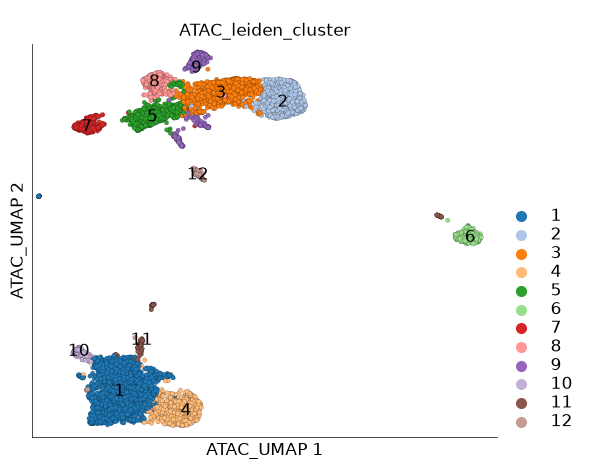

time: 420 ms (started: 2026-06-29 18:27:50 +02:00)


In [13]:
ds.plot_layout(layout_key="ATAC_UMAP", color_by="ATAC_leiden_cluster")

In [14]:
scarf.fetch_dataset(dataset_name="annotations", save_path="scarf_datasets")

time: 12.2 s (started: 2026-06-29 18:27:50 +02:00)


In [15]:
ds.add_melded_assay(
    from_assay="ATAC",
    external_bed_fn="scarf_datasets/annotations/human_GRCh37_gencode_v38_gene_body.bed.gz",
    peaks_col="ids",
    renormalization=False,
    assay_label="GeneScores",
    assay_type="RNA",
)

INFO: 33898/62409 features did not overlap with any peak


  0%|                                                                                                         …

OSError: [Errno 28] No space left on device

time: 59.8 s (started: 2026-06-29 18:28:03 +02:00)


In [16]:
ds

AttributeError: 'DataStore' object has no attribute 'GeneScores'

time: 116 ms (started: 2026-06-29 18:29:02 +02:00)


In [17]:
ds.plot_layout(
    layout_key="ATAC_UMAP",
    from_assay="GeneScores",
    color_by=["CD3D", "MS4A1", "LEF1", "NKG7", "TREM1", "LYZ"],
    clip_fraction=0.01,
    n_columns=3,
    width=3,
    height=3,
    point_size=5,
    scatter_kwargs={"lw": 0.01},
)

AttributeError: 'DataStore' object has no attribute 'GeneScores'

time: 72.3 ms (started: 2026-06-29 18:29:03 +02:00)
